## Plot Globally-averaged JPDF, divJPDF

In [1]:
#Load relevant packages
import xarray as xr
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from xhistogram.xarray import histogram
from typing import Annotated
import matplotlib.colors as colors
import cartopy.crs as ccrs
import scipy
import matplotlib.patches as patches
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 16})

from matplotlib import cm, ticker
from matplotlib import colors as cols

In [2]:
# open the data
hist_ds = xr.open_dataset('data/hist_full.nc',chunks={})
ds=xr.open_dataset('data/atlantic_vort_div_strain.nc')

In [3]:
hist_ds

<xarray.Dataset> Size: 31GB
Dimensions:              (time: 37, region: 437, vort_bin: 99, strain_bin: 49,
                          div_bin: 99, vertices: 4)
Coordinates: (12/13)
  * time                 (time) datetime64[ns] 296B 2011-09-17T22:30:00 ... 2...
    j_region_coarse      (region) int64 3kB dask.array<chunksize=(437,), meta=np.ndarray>
    region_num           (region) int64 3kB dask.array<chunksize=(437,), meta=np.ndarray>
    i_region_coarse      (region) int64 3kB dask.array<chunksize=(437,), meta=np.ndarray>
    face                 (region) int64 3kB dask.array<chunksize=(437,), meta=np.ndarray>
    region_wet_area      (region) float64 3kB dask.array<chunksize=(437,), meta=np.ndarray>
    ...                   ...
    lat                  (region) float32 2kB dask.array<chunksize=(437,), meta=np.ndarray>
    vertices_longitude   (vertices, region) float32 7kB dask.array<chunksize=(4, 437), meta=np.ndarray>
    vertices_latitude    (vertices, region) float32 7kB dask.array<chunksize=(4, 437), meta=np.ndarray>
  * vort_bin             (vort_bin) float64 792B -4.949 -4.848 ... 4.848 4.949
  * strain_bin           (strain_bin) float64 392B 0.05102 0.1531 ... 4.949
  * div_bin              (div_bin) float64 792B -4.949 -4.848 ... 4.848 4.949
Dimensions without coordinates: region, vertices
Data variables:
    probability_density  (time, region, vort_bin, strain_bin, div_bin) float32 31GB dask.array<chunksize=(1, 23, 99, 49, 99), meta=np.ndarray>

In [4]:
# functions to marginalize jpdf
def marginalize(pdf: xr.DataArray, dims: str | list = None) -> xr.DataArray:
    """
    Integrate out one or more dimensions of the PDF to remove dependence on that quantity,
    whilst still preserving the total integrated probability.
    """
       
    all_bin_dims = ['vort_bin', 'strain_bin', 'div_bin']
    
    if isinstance(dims, str):
        dims = [dims]
    
    if dims is None:
        dims=all_bin_dims
    
    if any(d not in all_bin_dims for d in dims):
        raise ValueError("Can't take marginal PDF over a dimension which is not a variable of the original PDF")
    
    marginal_pdf = pdf

    # TODO these might be more accurate if we used xarray's integrate function
    if 'vort_bin' in dims:
        vort_bin_width = pdf['vort_bin'].diff('vort_bin')[0]
        marginal_pdf = marginal_pdf.sum(dim='vort_bin') * vort_bin_width
        
    if 'strain_bin' in dims:
        strain_bin_width = pdf['strain_bin'].diff('strain_bin')[0]
        marginal_pdf = marginal_pdf.sum(dim='strain_bin') * strain_bin_width
        
    if 'div_bin' in dims:
        div_bin_width = pdf['div_bin'].diff('div_bin')[0]
        marginal_pdf = marginal_pdf.sum(dim='div_bin') * div_bin_width
        
    return marginal_pdf


def expectation(pdf: xr.DataArray, x: xr.DataArray, dims: str | list = None) -> xr.DataArray:
    """
    Take the expectation value of x over the given Probability Density Function.
    """
    
    return marginalize(pdf * x, dims=dims)

In [5]:
@xr.register_dataarray_accessor("pdf")
class DataArrayPDFAccessor:
    def __init__(self, da: xr.DataArray):
        self._da = da
        
    def marginalize(self, dims: str | list = None) -> xr.DataArray:
        return marginalize(self._da, dims=dims)
    
    def expectation(self, x, dims: str | list = None) -> xr.DataArray:
        return expectation(self._da, x, dims=dims)

In [6]:
h = hist_ds['probability_density']
h['center_lat'] = hist_ds.vertices_latitude.mean('vertices')
h['center_lon'] = hist_ds.vertices_longitude.mean('vertices')
max_vert = abs(hist_ds.vertices_longitude.diff('vertices')).max('vertices')
h['center_lon'] = h['center_lon'].where(max_vert<100,((hist_ds.vertices_longitude.where(max_vert>100).min('vertices') +hist_ds.vertices_longitude.where(max_vert>100).max('vertices')+360)/2))
h1 = h.mean('time')
h1_global = h1.weighted(h1['region_wet_area']).mean('region')

In [7]:
h1_2d = h1_global.pdf.marginalize('div_bin')*(h1_global['vort_bin'].diff('vort_bin')[0]*h1_global['strain_bin'].diff('strain_bin')[0])
div_2d = ((h1_global.div_bin*h1_global).sum('div_bin')).load()/((h1_global).sum('div_bin'))
h1_2d_masked = h1_2d.where(h1_2d>10**-5)
div_2d_masked = div_2d.where(h1_2d>10**-5)

In [8]:


ζ_coarse = ds.vorticity_coarsened
σ_coarse = ds.strain_coarsened
D_coarse = ds.divergence_coarsened

Xζ_coarse = ds.Xζ
Yζ_coarse = ds.Yζ
XC_coarse = ds.XC
YC_coarse = ds.YC

In [9]:
import cartopy.crs as ccrs
from matplotlib.colors import BoundaryNorm

In [10]:
import matplotlib.ticker as mticker

<>:153: SyntaxWarning: invalid escape sequence '\z'
<>:154: SyntaxWarning: invalid escape sequence '\s'
<>:176: SyntaxWarning: invalid escape sequence '\z'
<>:153: SyntaxWarning: invalid escape sequence '\z'
<>:154: SyntaxWarning: invalid escape sequence '\s'
<>:176: SyntaxWarning: invalid escape sequence '\z'
/tmp/ipykernel_1163/59226984.py:153: SyntaxWarning: invalid escape sequence '\z'
  ax4.set_xlabel('$\zeta/f_{floor}$')
/tmp/ipykernel_1163/59226984.py:154: SyntaxWarning: invalid escape sequence '\s'
  ax4.set_ylabel('$\sigma/f_{floor}$')
/tmp/ipykernel_1163/59226984.py:176: SyntaxWarning: invalid escape sequence '\z'
  ax5.set_xlabel('$\zeta/f_{floor}$')


<Figure size 640x480 with 0 Axes>

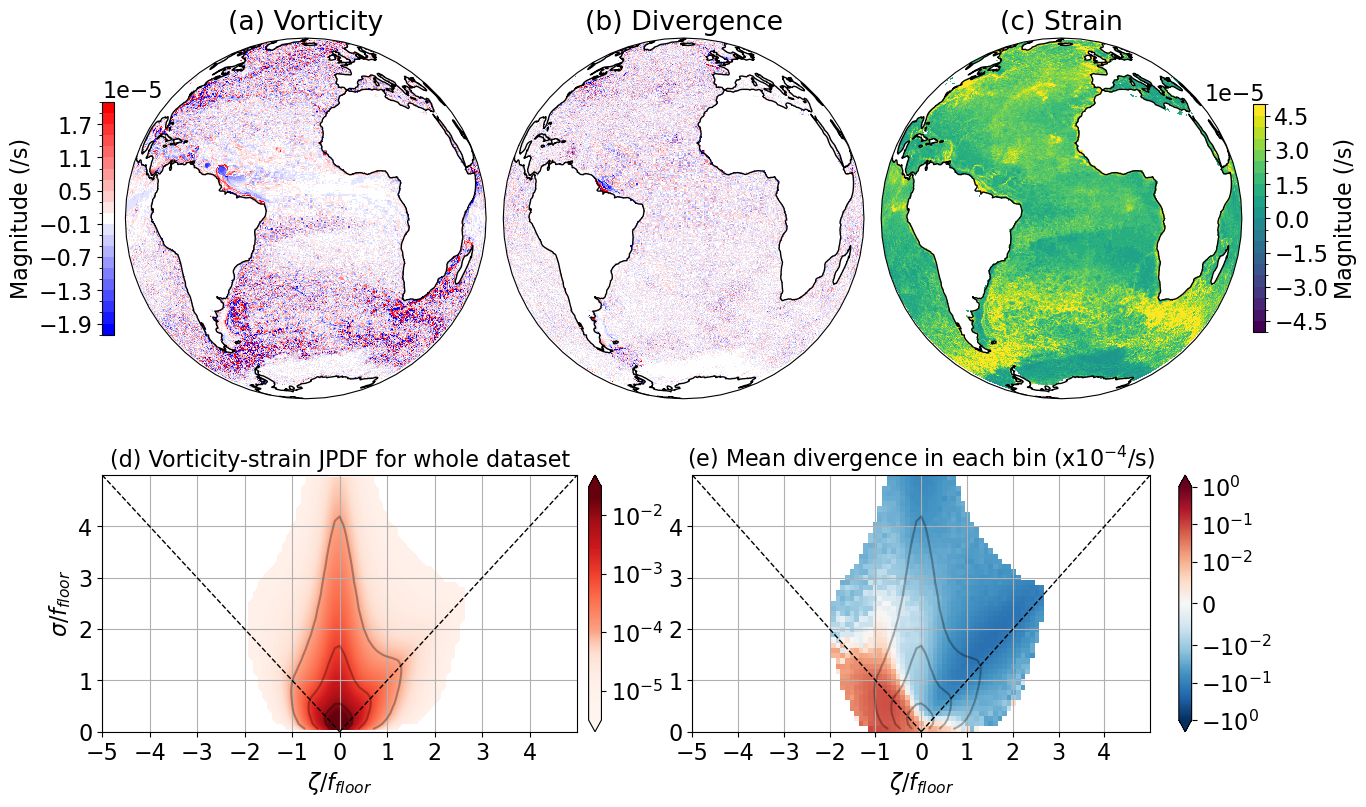

In [11]:
plt.clf()

fig = plt.figure(figsize=(15, 10))

gs = fig.add_gridspec(
    nrows=2,
    ncols=6,
    height_ratios=[1, 0.5],
    hspace=0,
    wspace=0.1
)

# ----------------------------
# Projections / axes
# ----------------------------
proj = ccrs.Orthographic(
    central_longitude=-22,
    central_latitude=-10
)

# Top row: 3 Cartopy axes
ax1 = fig.add_subplot(gs[0, 0:2], projection=proj)
ax2 = fig.add_subplot(gs[0, 2:4], projection=proj)
ax3 = fig.add_subplot(gs[0, 4:6], projection=proj)

# Bottom row: 2 regular axes
ax4 = fig.add_subplot(gs[1, 0:3])
ax5 = fig.add_subplot(gs[1, 3:6])

# ----------------------------
# Colormap / normalization
# ----------------------------
cmap = plt.get_cmap("bwr").copy()
cmap.set_bad("white")

cmap2 = plt.get_cmap("viridis").copy()
cmap2.set_bad("white")

levels = np.arange(-0.21*10**-4, 0.211*10**-4, 0.000002)
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)


levels2 = np.arange(-0.5*10**-4, 0.51*10**-4, 0.000005)
norm2 = BoundaryNorm(levels2, ncolors=cmap.N, clip=True)
# ----------------------------
# Top subplot 1
# ----------------------------
Z1 = np.ma.masked_invalid(ζ_coarse.values)

cp1 = ax1.pcolormesh(
    Xζ_coarse.values,
    Yζ_coarse.values,
    Z1,
    transform=ccrs.PlateCarree(),
    cmap=cmap,
    norm=norm,
    shading="auto"
)

ax1.coastlines()
ax1.set_facecolor("white")
ax1.set_title("(a) Vorticity")


# ----------------------------
# Top subplot 2
# Replace data here as needed
# ----------------------------
Z2 = np.ma.masked_invalid(D_coarse.values)

cp2 = ax2.pcolormesh(
    XC_coarse.values,
    YC_coarse.values,
    Z2,
    transform=ccrs.PlateCarree(),
    cmap=cmap,
    norm=norm,
    shading="auto"
)

ax2.coastlines()
ax2.set_facecolor("white")
ax2.set_title("(b) Divergence")

# ----------------------------
# Top subplot 3
# Replace data here as needed
# ----------------------------
Z3 = np.ma.masked_invalid(σ_coarse.values)

cp3 = ax3.pcolormesh(
    Xζ_coarse.values,
    Yζ_coarse.values,
    Z3,
    transform=ccrs.PlateCarree(),
    cmap=cmap2,
    norm=norm2,
    shading="auto"
)

ax3.coastlines()
ax3.set_facecolor("white")
ax3.set_title("(c) Strain")

# Shared colorbar for top row
cbar = fig.colorbar(
    cp1,
    ax=[ax1,ax2,ax3],
    orientation="vertical",
    location="left",
    fraction=0.01,
    pad=0.01
)
cbar.set_label("Magnitude (/s)")
#cbar.ax.xaxis.set_label_position("left")
#cbar.ax.xaxis.set_ticks_position("left")

cbar2 = fig.colorbar(
    cp3,
    ax=[ax1,ax2,ax3],
    orientation="vertical",
    location="right",
    fraction=0.01,
    pad=0.01
)
cbar2.set_label("Magnitude (/s)")
#cbar2.ax.xaxis.set_label_position("top")
#cbar2.ax.xaxis.set_ticks_position("top")

# ----------------------------
# Bottom subplot 1
# Replace with your actual non-Cartopy plot
# ----------------------------

log_formatter = mticker.LogFormatterMathtext(base=10)
levels = 10**(np.arange(-5.5, -1.5, 0.01))
h1_2d_masked.plot.contourf(x='vort_bin', ax=ax4, vmax=0.02,norm=cols.SymLogNorm(1e-4), cmap='Reds',
                    vmin=10**-5.5,levels=levels,extend='both',cbar_kwargs={'ticks': [10**-5, 10**-4, 10**-3, 10**-2],'format': log_formatter,'label':'', 'pad': 0.02})

h1_2d.plot.contour(x='vort_bin',ax=ax4, levels=[1e-2, 1e-3, 1e-4], colors='k', alpha=.3)
ax4.plot(np.linspace(0,5), np.linspace(0,5),color='k',linewidth=1,linestyle='--')
ax4.plot(np.linspace(-5,0), np.linspace(5,0),color='k',linewidth=1,linestyle='--')
x_ticks = np.arange(-5, 5)
y_ticks = np.arange(0, 5)

ax4.set_xticks(x_ticks)

ax4.set_yticks(y_ticks)


ax4.set_xlim(-5,5)
ax4.set_ylim(0,5)
ax4.set_xlabel('$\zeta/f_{floor}$')
ax4.set_ylabel('$\sigma/f_{floor}$')
plt.rc('grid', color='black', alpha=.3)
ax4.grid()

ax4.set_title('(d) Vorticity-strain JPDF for whole dataset',fontsize=16)

# ----------------------------
# Bottom subplot 2
# Replace with your actual non-Cartopy plot
# ----------------------------
levels = 10**(np.arange(-5.5, -1.5, 0.1))

h1_2d.plot.contour(x='vort_bin',ax=ax5, levels=[1e-2, 1e-3, 1e-4], colors='k', alpha=.3)

div_2d_masked.plot(x='vort_bin',ax=ax5,vmax=1, norm=cols.SymLogNorm(1e-2), extend='both', cmap='RdBu_r')


ax5.plot(np.linspace(0,5), np.linspace(0,5),color='k',linewidth=1,linestyle='--')
ax5.plot(np.linspace(-5,0), np.linspace(5,0),color='k',linewidth=1,linestyle='--')

ax5.set_xlim(-5,5)
ax5.set_ylim(0,5)
ax5.set_xlabel('$\zeta/f_{floor}$')
ax5.set_ylabel('')
plt.grid()

x_ticks = np.arange(-5, 5)
y_ticks = np.arange(0, 5)

ax5.set_xticks(x_ticks)

ax5.set_yticks(y_ticks)



plt.title('(e) Mean divergence in each bin (x$ 10^{-4}$/s)',fontsize=16)

fig.savefig('vort_strain.png')